# Project A – Inverse PINN for Young’s Modulus Recovery

**Method:** Physics‑Informed Neural Network (PINN) with a neural network for $k(x)$
and a soft trigonometric regularisation.

We solve the 1D elastostatics equation
$$-\frac{d}{dx}\!\left(k(x)\frac{du}{dx}\right) = f = 9.81,\qquad u(0)=u(1)=0,$$
to recover the unknown spatially varying Young’s modulus $k(x)$ from 500 noisy displacement observations.

In [22]:
import numpy as np
import torch
import torch.nn as nn
from torch.autograd import grad
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import h5py
import time
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float32
print(f'Using device: {device}')

Using device: cuda


In [23]:
# Paths
script_dir = os.path.abspath('')               # current working directory (project_A)
project_root = os.path.dirname(script_dir)      # parent directory (dl-pdes-tum-project)
data_path = os.path.join(project_root, 'data', 'ProblemA_dataset.h5')
output_dir = os.path.join(script_dir, 'Results_ProjectA')
os.makedirs(output_dir, exist_ok=True)

# Load dataset
with h5py.File(data_path, 'r') as f:
    x_obs = torch.tensor(np.array(f['x_obs']), dtype=dtype).reshape(-1,1).to(device)
    u_obs = torch.tensor(np.array(f['u_obs']), dtype=dtype).reshape(-1,1).to(device)
    x_test = torch.tensor(np.array(f['x_test']), dtype=dtype).reshape(-1,1).to(device)
    k_test = torch.tensor(np.array(f['k_test']), dtype=dtype).reshape(-1,1).to(device)
    u_test = torch.tensor(np.array(f['u_test']), dtype=dtype).reshape(-1,1).to(device)

print('x_obs shape:', x_obs.shape, 'u_obs shape:', u_obs.shape)
print('x_test shape:', x_test.shape, 'k_test shape:', k_test.shape)

x_obs shape: torch.Size([500, 1]) u_obs shape: torch.Size([500, 1])
x_test shape: torch.Size([10001, 1]) k_test shape: torch.Size([10001, 1])


## Step 1: Neural networks for $u$ and $k$

- **$u_\theta(x)$:** MLP with sinusoidal activation $\sin(\pi x+\pi)+\sin(x)$.
- **$k_\phi(x)$:** MLP with the same sinusoidal activation + `softplus` to ensure positivity.

The network $k_\phi$ is the **primary** representation of the Young’s modulus.
We will later add a soft regularisation that encourages it to stay near a learned
trigonometric shape – but the network is free to deviate if required by the physics.

In [24]:
class MLP_u(nn.Module):
    def __init__(self, layers_list):
        super().__init__()
        layers = []
        in_dim = layers_list[0]
        for out_dim in layers_list[1:]:
            layers.append(nn.Linear(in_dim, out_dim, dtype=dtype))
            in_dim = out_dim
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        for layer in self.net[:-1]:
            x = layer(x)
            x = torch.sin(np.pi * x + np.pi) + torch.sin(x)
        x = self.net[-1](x)
        return x

u_net = MLP_u([1, 60, 60, 60, 60, 1]).to(device)

class MLP_k(nn.Module):
    def __init__(self, layers_list):
        super().__init__()
        layers = []
        in_dim = layers_list[0]
        for out_dim in layers_list[1:]:
            layers.append(nn.Linear(in_dim, out_dim, dtype=dtype))
            in_dim = out_dim
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        for layer in self.net[:-1]:
            x = layer(x)
            x = torch.sin(np.pi * x + np.pi) + torch.sin(x)
        x = self.net[-1](x)
        return nn.functional.softplus(x)   # ensures k > 0

k_net = MLP_k([1, 60, 60, 60, 60, 1]).to(device)

## Step 2: Learnable trigonometric reference for regularisation

We define a simple three‑parameter trigonometric shape
$$k_{\text{trig}}(x) = B + w_1\sin^2(2\pi x) + w_2\sin^2(\pi x)$$
that can represent two humps. The parameters $B, w_1, w_2$ are **learnable** – they are
not fixed a priori. This shape will be used only as a **soft regularisation** to guide
$k_\phi$, not as the actual $k(x)$.

In [25]:
B  = torch.tensor(1.0,    dtype=dtype, device=device, requires_grad=True)
w1 = torch.tensor(1.0,    dtype=dtype, device=device, requires_grad=True)
w2 = torch.tensor(0.2,    dtype=dtype, device=device, requires_grad=True)

def k_trig(x):
    """Learnable trigonometric reference shape."""
    return B + w1 * torch.sin(2 * np.pi * x)**2 + w2 * torch.sin(np.pi * x)**2

def loss_reg(x):
    """Soft regularisation: encourages k_net to stay close to the trig shape."""
    k_nn = k_net(x)
    k_ref = k_trig(x)
    return nn.MSELoss()(k_nn, k_ref)

## Step 3: Collocation points and boundary conditions

- **Collocation points:** 20,000 random interior points for the PDE residual.
- **Boundary points:** $x=0$ and $x=1$, where $u$ is forced to zero.

The 500 observation sensors from the dataset are used **only** in the data loss.

In [26]:
n_collocation = 20000
x_in = torch.rand(n_collocation, 1, device=device)

class MyDataset(Dataset):
    def __init__(self, x): self.x = x
    def __getitem__(self, idx): return self.x[idx]
    def __len__(self): return len(self.x)

dataloader = DataLoader(MyDataset(x_in), batch_size=2000, shuffle=True)

x_bd = torch.tensor([[0.0], [1.0]], dtype=dtype).to(device)
u_bd = torch.zeros(2, 1, dtype=dtype).to(device)

# Fixed validation set for early stopping
x_val = torch.rand(2000, 1, device=device)

## Step 4: Loss functions

$$\mathcal{L} = w_{\text{data}}\mathcal{L}_{\text{data}} + w_{\text{pde}}\mathcal{L}_{\text{pde}} + w_{\text{bc}}\mathcal{L}_{\text{bc}} + w_{\text{reg}}\mathcal{L}_{\text{reg}}$$

- **Data loss** – MSE between $u_\theta$ and noisy $u_{\text{obs}}$ at the 500 sensors.
- **PDE residual** – $-\frac{d}{dx}(k\frac{du}{dx}) - 9.81$, averaged over collocation points.
- **BC loss** – $u_\theta(0)^2 + u_\theta(1)^2$.
- **Regularisation loss** – MSE between $k_\phi(x)$ and the learned trigonometric reference.
  This term gently pushes the network towards a two‑peak shape, but the PDE and data
  losses can override it if necessary.

In [27]:
mse = nn.MSELoss()
f_val = 9.81

def loss_data():
    return mse(u_net(x_obs), u_obs)

def loss_bc():
    return mse(u_net(x_bd), u_bd)

def loss_pde(x):
    x.requires_grad_(True)
    u = u_net(x)
    k = k_net(x)          # neural network for k
    du = grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    flux = k * du
    dflux = grad(flux, x, grad_outputs=torch.ones_like(flux), create_graph=True)[0]
    residual = -dflux - f_val
    return torch.mean(residual ** 2)

## Step 5: Training

- **Optimiser:** Adam ($\text{lr}=5\times10^{-4}$)
- **Scheduler:** ReduceLROnPlateau (factor 0.8, patience 20)
- **Gradient clipping:** max norm 1.0
- **Early stopping:** best model according to validation PDE loss is kept.
- **Fine‑tuning:** 200 L‑BFGS steps after Adam.

In [28]:
params = list(u_net.parameters()) + list(k_net.parameters()) + [B, w1, w2]
optimizer = torch.optim.Adam(params, lr=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.8, patience=20)

# Loss weights (tuned empirically)
w_data = 1.0
w_pde  = 20.0
w_bc   = 10.0
w_reg  = 100.0   # high weight – strong prior for two peaks

epochs = 600
error_u_hist, error_k_hist = [], []
train_loss_hist, val_pde_hist = [], []   # for loss curves
time_per_epoch = []
val_pde_loss_best = float('inf')
best_state = None

print("Training PINN with soft trigonometric regularisation ...")
for epoch in range(epochs):
    t0 = time.time()
    for x_batch in dataloader:
        L_data = loss_data()
        L_pde  = loss_pde(x_batch.view(-1, 1))
        L_bc   = loss_bc()
        L_reg  = loss_reg(x_batch.view(-1, 1))
        total_loss = w_data * L_data + w_pde * L_pde + w_bc * L_bc + w_reg * L_reg

        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
        optimizer.step()

    val_pde = loss_pde(x_val).item()
    scheduler.step(val_pde)
    time_per_epoch.append(time.time() - t0)

    # Record losses
    train_loss_hist.append(total_loss.item())
    val_pde_hist.append(val_pde)

    # Save best model
    if val_pde < val_pde_loss_best:
        val_pde_loss_best = val_pde
        best_state = {
            'u_net': {k: v.cpu().clone() for k, v in u_net.state_dict().items()},
            'k_net': {k: v.cpu().clone() for k, v in k_net.state_dict().items()},
            'trig_params': [B.detach().cpu().clone(), w1.detach().cpu().clone(), w2.detach().cpu().clone()]
        }

    # Compute test errors (monitoring only)
    with torch.no_grad():
        u_pred = u_net(x_test)
        k_pred = k_net(x_test)
        err_u = torch.sqrt(torch.sum((u_pred - u_test)**2) / torch.sum(u_test**2)).item()
        err_k = torch.sqrt(torch.sum((k_pred - k_test)**2) / torch.sum(k_test**2)).item()
        error_u_hist.append(err_u)
        error_k_hist.append(err_k)

    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1:3d}: loss={total_loss.item():.6e}, err_u={err_u:.4f}, err_k={err_k:.4f}")

# Restore best model
if best_state is not None:
    u_net.load_state_dict(best_state['u_net'])
    k_net.load_state_dict(best_state['k_net'])
    for p, val in zip([B, w1, w2], best_state['trig_params']):
        p.data.copy_(val.to(device))
    print("Restored best model.")

Training PINN with soft trigonometric regularisation ...
Epoch 100: loss=3.608747e+00, err_u=0.0246, err_k=0.0775
Epoch 200: loss=1.499013e-01, err_u=0.0210, err_k=0.0831
Epoch 300: loss=4.149732e-02, err_u=0.0198, err_k=0.0848
Epoch 400: loss=1.242017e-02, err_u=0.0190, err_k=0.0852
Epoch 500: loss=6.015157e-03, err_u=0.0194, err_k=0.0854
Epoch 600: loss=4.396288e-03, err_u=0.0196, err_k=0.0858
Restored best model.


In [29]:
print("Fine‑tuning with L‑BFGS...")
optimizer_lbfgs = torch.optim.LBFGS(params, lr=0.5, max_iter=200,
                                    tolerance_grad=1e-9, line_search_fn='strong_wolfe')
def closure():
    optimizer_lbfgs.zero_grad()
    L_data = loss_data()
    L_pde  = loss_pde(x_val)
    L_bc   = loss_bc()
    L_reg  = loss_reg(x_val)
    total = w_data * L_data + w_pde * L_pde + w_bc * L_bc + w_reg * L_reg
    total.backward()
    return total
optimizer_lbfgs.step(closure)

# Final errors
with torch.no_grad():
    u_pred = u_net(x_test)
    k_pred = k_net(x_test)
    err_u_final = torch.sqrt(torch.sum((u_pred - u_test)**2) / torch.sum(u_test**2)).item()
    err_k_final = torch.sqrt(torch.sum((k_pred - k_test)**2) / torch.sum(k_test**2)).item()

print(f"\nFinal L2 errors — u: {err_u_final:.4f}, k: {err_k_final:.4f}")
print(f"Trig parameters: B={B.item():.6f}, w1={w1.item():.6f}, w2={w2.item():.6f}")

Fine‑tuning with L‑BFGS...

Final L2 errors — u: 0.0194, k: 0.0851
Trig parameters: B=1.072757, w1=0.733307, w2=0.116715


## Results

Plots of predicted vs. true $u(x)$ and $k(x)$, pointwise absolute error,
and convergence history.

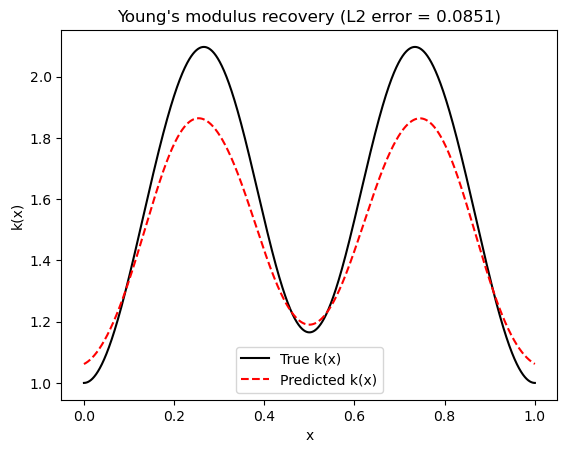

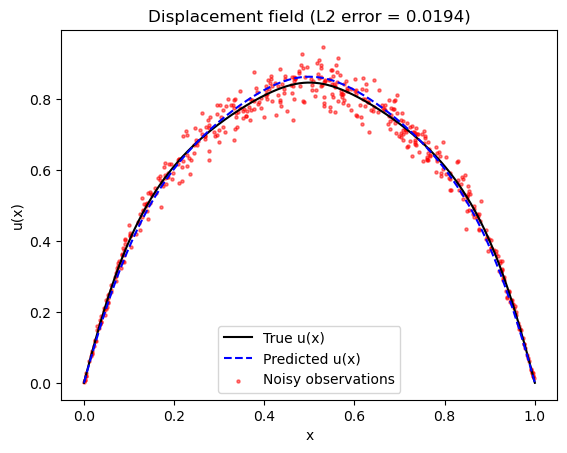

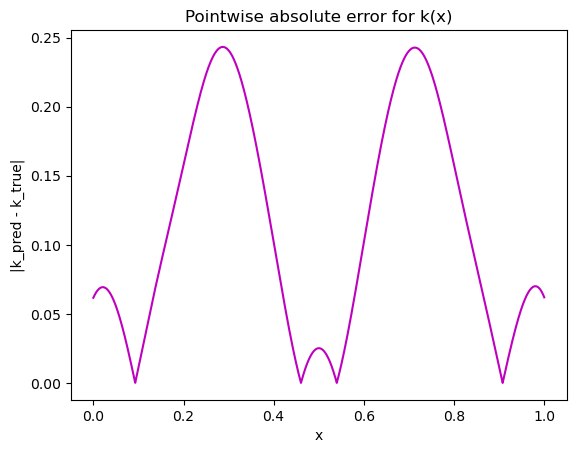

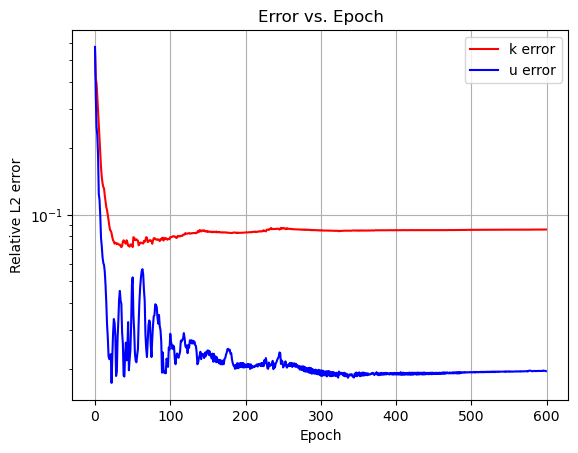

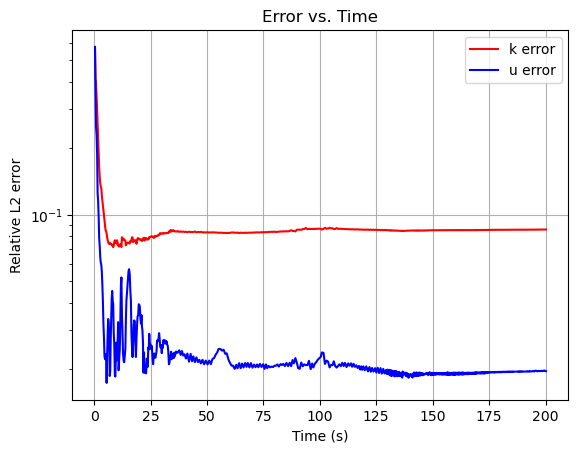

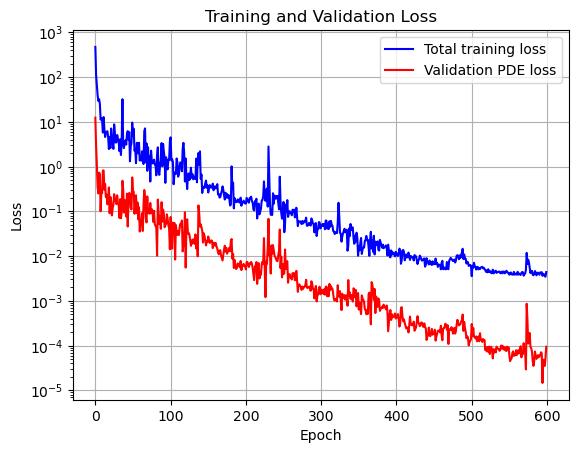

In [30]:
x_t = x_test.cpu().numpy().flatten()
u_t = u_test.cpu().numpy().flatten()
k_t = k_test.cpu().numpy().flatten()
u_p = u_pred.cpu().numpy().flatten()
k_p = k_pred.cpu().numpy().flatten()

# 1. k comparison
plt.figure()
plt.plot(x_t, k_t, 'k-', label='True k(x)')
plt.plot(x_t, k_p, 'r--', label='Predicted k(x)')
plt.xlabel('x'); plt.ylabel('k(x)')
plt.legend()
plt.title(f'Young\'s modulus recovery (L2 error = {err_k_final:.4f})')
plt.savefig(os.path.join(output_dir, 'k_comparison.png'))
plt.show()

# 2. u comparison
plt.figure()
plt.plot(x_t, u_t, 'k-', label='True u(x)')
plt.plot(x_t, u_p, 'b--', label='Predicted u(x)')
plt.scatter(x_obs.cpu(), u_obs.cpu(), s=5, c='red', alpha=0.5, label='Noisy observations')
plt.xlabel('x'); plt.ylabel('u(x)')
plt.legend()
plt.title(f'Displacement field (L2 error = {err_u_final:.4f})')
plt.savefig(os.path.join(output_dir, 'u_comparison.png'))
plt.show()

# 3. Pointwise absolute error for k
plt.figure()
plt.plot(x_t, np.abs(k_p - k_t), 'm-')
plt.xlabel('x'); plt.ylabel('|k_pred - k_true|')
plt.title('Pointwise absolute error for k(x)')
plt.savefig(os.path.join(output_dir, 'k_pointwise_error.png'))
plt.show()

# 4. Error vs. epoch
plt.figure()
plt.plot(error_k_hist, 'r-', label='k error')
plt.plot(error_u_hist, 'b-', label='u error')
plt.yscale('log')
plt.xlabel('Epoch'); plt.ylabel('Relative L2 error')
plt.legend()
plt.title('Error vs. Epoch')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'error_vs_epoch.png'))
plt.show()

# 5. Error vs. time
cum_time = np.cumsum(time_per_epoch)
plt.figure()
plt.semilogy(cum_time, error_k_hist, 'r-', label='k error')
plt.semilogy(cum_time, error_u_hist, 'b-', label='u error')
plt.xlabel('Time (s)'); plt.ylabel('Relative L2 error')
plt.legend()
plt.title('Error vs. Time')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'error_vs_time.png'))
plt.show()

# 6. Training and validation loss
plt.figure()
plt.plot(train_loss_hist, 'b-', label='Total training loss')
plt.plot(val_pde_hist, 'r-', label='Validation PDE loss')
plt.yscale('log')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'loss_history.png'))
plt.show()